# Хакатон RLT: исследование данных и предобработка

Ноутбук разбирает три выгрузки (`Извещения`, `ТРУ`, `Поставщики`), проверяет качество данных и готовит очищенные таблицы для модели подбора контрагентов.

**Вход:** CSV-файлы в папке проекта.
**Выход:** `data/processed/*.parquet`:

| Файл | Строка = | Назначение |
|---|---|---|
| `lots.parquet` | лот | Извещение + агрегаты по ТРУ и участникам, очищенный текст, сплит по времени |
| `tru.parquet` | уникальная позиция лота | Очищенное название, лемматизированный текст, уровни ОКПД2 |
| `suppliers.parquet` | пара «лот × поставщик» | Проверенные ИНН, признак победы, регион |
| `okpd2_classes.parquet` | класс ОКПД2 | Справочник названий классов (2 знака) |

Исходя из договорённости команды, на вход сервису подаются **извещения + ТРУ**, а таблица поставщиков используется только как разметка для обучения и оценки.

In [1]:
import re, time, json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)
pd.set_option('display.max_colwidth', 120)

DATA_DIR = Path('.')
OUT_DIR = Path('data/processed')
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find(prefix):
    files = sorted(DATA_DIR.glob(f'{prefix}*.csv'))
    assert files, f'не найден файл {prefix}*.csv'
    return files[0]

FILES = {'notices': find('Извещения'), 'tru': find('ТРУ'), 'suppliers': find('Поставщики')}

def fmt(x):
    return f'{x:,.0f}'.replace(',', ' ')

def pct(x):
    return f'{100 * x:.1f}%'

FILES

{'notices': WindowsPath('Извещения_24-25.csv'),
 'tru': WindowsPath('ТРУ_24-25.csv'),
 'suppliers': WindowsPath('Поставщики_24-25.csv')}

In [2]:
# Единый стиль графиков: тонкие марки, приглушённые оси и сетка, фиксированные цвета площадок
C_BLUE, C_ORANGE, C_AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, GRID, SURF = '#0b0b0b', '#52514e', '#e4e3df', '#fcfcfb'
PLAT_COLOR = {'АИС ГЗ': C_BLUE, 'ЭМ': C_ORANGE}

mpl.rcParams.update({
    'figure.facecolor': SURF, 'axes.facecolor': SURF, 'savefig.facecolor': SURF,
    'figure.dpi': 110, 'font.size': 10,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left', 'axes.titlepad': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'xtick.color': INK2, 'ytick.color': INK2, 'xtick.major.size': 0, 'ytick.major.size': 0,
    'legend.frameon': False, 'legend.labelcolor': INK,
    'lines.linewidth': 2,
})

def thousands(ax, axis='y'):
    f = mpl.ticker.FuncFormatter(lambda v, _: fmt(v))
    (ax.yaxis if axis == 'y' else ax.xaxis).set_major_formatter(f)

## 1. Загрузка

Все поля читаются как строки: так не теряются ведущие нули в ИНН и КПП, а типы приводятся явно на этапе предобработки.

In [3]:
def load(path):
    t0 = time.time()
    df = pd.read_csv(path, sep=';', dtype=str, encoding='utf-8')
    mb = df.memory_usage(deep=True).sum() / 2**20
    print(f'{path.name}: {fmt(len(df))} строк × {df.shape[1]} колонок, {mb:,.0f} МБ в памяти, {time.time() - t0:.0f} с')
    return df

notices = load(FILES['notices'])
tru = load(FILES['tru'])
sup = load(FILES['suppliers'])

Извещения_24-25.csv: 604 452 строк × 11 колонок, 624 МБ в памяти, 12 с


ТРУ_24-25.csv: 2 971 651 строк × 3 колонок, 841 МБ в памяти, 14 с


Поставщики_24-25.csv: 1 010 138 строк × 4 колонок, 214 МБ в памяти, 3 с


In [4]:
def profile(df):
    rows = []
    for c in df.columns:
        s = df[c]
        ln = s.str.len()
        rows.append({
            'колонка': c,
            'пропусков': int(s.isna().sum()),
            'пропусков, %': round(100 * s.isna().mean(), 2),
            'уникальных': int(s.nunique()),
            'длина мин': ln.min(), 'длина медиана': ln.median(), 'длина макс': ln.max(),
            'пример': s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(rows).set_index('колонка')

display(notices.head(3), tru.head(3), sup.head(3))

,publish_date,procedure_id,lot_id,start_price,reqnum,procedure_name,subject,is_smp,customer_inn,customer_kpp,is_eshop_or_aisgz
0,2024-07-11,1841706,2077538,530000.00,NaN,Преподавательские услуги (п.33 ч.1 ст.93 Федерального закона №44-ФЗ),Преподавательские услуги (п.33 ч.1 ст.93 Федерального закона №44-ФЗ),false,7804105239,780401001,АИС ГЗ
1,2024-01-18,4021762,4257576,2835.54,NaN,Оказание услуг связи,Оказание услуг связи,false,7807022750,780701001,АИС ГЗ
2,2024-12-06,4397352,4633163,13500.00,NaN,"Приобретение неисключительных прав использования программного комплекса ""СБиС""","Приобретение неисключительных прав использования программного комплекса ""СБиС""",false,7805149197,780501001,АИС ГЗ


,lot_id,product_name,okpd2_code
0,4257576,Услуги связи,61.10.11.110
1,4633163,"Приобретение неисключительных прав использования программного комплекса ""СБиС""",58.29.50.000
2,4652711,Услуги по ремонту и техническому обслуживанию оборудования общего назначения,33.12.1


,lot_id,supplier_inn,supplier_kpp,is_winner
0,4257576,7707049388,784201001,true
1,4633163,7605016030,763945001,true
2,4652711,636200108061,780601001,false


## 2. Извещения

Одна строка = один лот закупки. Поля: дата публикации, ID процедуры и лота, НМЦК (`start_price`), реестровый номер ЕИС (`reqnum`), название процедуры и предмет, признак закупки у МСП, ИНН/КПП заказчика, площадка (`АИС ГЗ` или `ЭМ`).

In [5]:
profile(notices)

,пропусков,"пропусков, %",уникальных,длина мин,длина медиана,длина макс,пример
колонка,,,,,,,
publish_date,0,0.0,705,10.0,10.0,10.0,2024-07-11
procedure_id,0,0.0,604452,7.0,7.0,7.0,1841706
lot_id,0,0.0,604452,7.0,7.0,7.0,2077538
start_price,3,0.0,330186,4.0,8.0,14.0,530000.00
reqnum,372939,61.7,231513,19.0,19.0,19.0,0172200004923000344
procedure_name,0,0.0,375110,3.0,89.0,1926.0,Преподавательские услуги (п.33 ч.1 ст.93 Федерального закона №44-ФЗ)
subject,0,0.0,373993,1.0,89.0,1926.0,Преподавательские услуги (п.33 ч.1 ст.93 Федерального закона №44-ФЗ)
is_smp,0,0.0,2,4.0,5.0,5.0,false
customer_inn,8449,1.4,2785,10.0,10.0,10.0,7804105239


In [6]:
print('lot_id уникален:', notices.lot_id.is_unique, '| procedure_id уникален:', notices.procedure_id.is_unique)
print('Процедур с несколькими лотами:', (notices.groupby('procedure_id').lot_id.nunique() > 1).sum())

n = notices.copy()
n['date'] = pd.to_datetime(n.publish_date, errors='coerce')
print('Нераспознанных дат:', n.date.isna().sum(), '| диапазон:', n.date.min().date(), '—', n.date.max().date())
n['month'] = n.date.dt.to_period('M')
pd.crosstab(n.date.dt.year, n.is_eshop_or_aisgz, margins=True, margins_name='всего')

lot_id уникален: True | procedure_id уникален: True


Процедур с несколькими лотами: 0
Нераспознанных дат: 0 | диапазон: 2024-01-08 — 2025-12-31


is_eshop_or_aisgz,АИС ГЗ,ЭМ,всего
date,,,
2024,169494,134044,303538
2025,163152,137762,300914
всего,332646,271806,604452


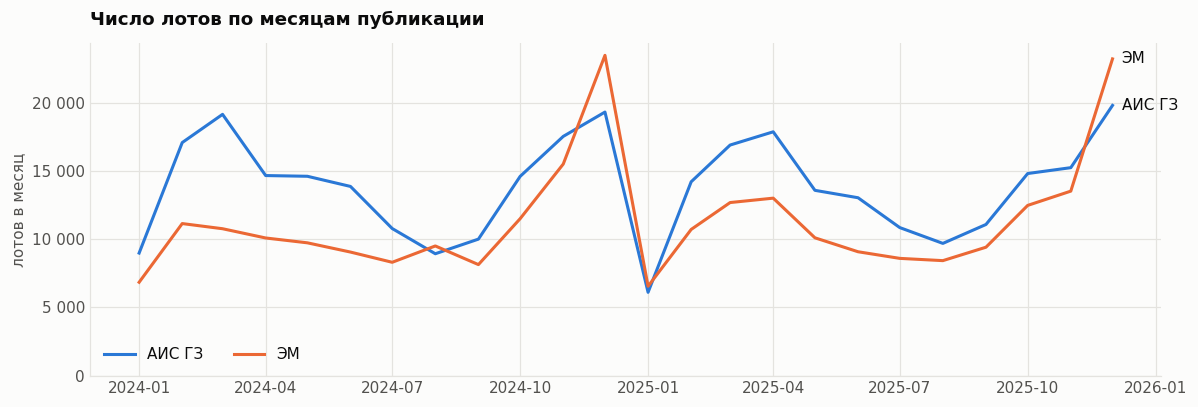

In [7]:
m = n.groupby(['month', 'is_eshop_or_aisgz']).size().unstack()
x = m.index.to_timestamp()
fig, ax = plt.subplots(figsize=(11, 3.8))
for p in ['АИС ГЗ', 'ЭМ']:
    ax.plot(x, m[p], color=PLAT_COLOR[p], label=p)
    ax.annotate(p, (x[-1], m[p].iloc[-1]), xytext=(6, 0), textcoords='offset points', va='center', color=INK)
ax.set_title('Число лотов по месяцам публикации')
ax.set_ylabel('лотов в месяц'); ax.set_ylim(0); thousands(ax)
ax.legend(loc='lower left', ncol=2)
plt.tight_layout(); plt.show()

### 2.1 НМЦК (`start_price`)

In [8]:
n['price'] = pd.to_numeric(n.start_price, errors='coerce')
print('Не число:', n.price.isna().sum(), '| ноль:', (n.price == 0).sum(), '| > 1 млрд ₽:', (n.price > 1e9).sum())
display(n.groupby('is_eshop_or_aisgz').price.describe(percentiles=[.01, .1, .5, .9, .99, .999]).T.map(fmt))
display(n.nlargest(5, 'price')[['lot_id', 'is_eshop_or_aisgz', 'price', 'subject']])

Не число: 3 | ноль: 21 | > 1 млрд ₽: 137


is_eshop_or_aisgz,АИС ГЗ,ЭМ
count,332 643,271 806
mean,3 331 796,463 465
std,109 870 010,83 903 258
min,0,0
1%,1 150,854
10%,8 176,7 550
50%,167 172,55 000
90%,2 693 432,423 304
99%,33 270 655,599 583
99.9%,333 684 000,600 000


,lot_id,is_eshop_or_aisgz,price,subject
24311,5012489,АИС ГЗ,3.999191e+10,Выполнение работ по объекту «Новая транспортная магистраль с мостом через р.Неву в створе Б.Смоленского пр. – ул.Кол...
237491,5369122,ЭМ,3.039986e+10,Оказание услуг по техническому обслуживанию и текущему ремонту автоэвакуаторов с гидроманипулятором в период с 01.12...
326266,5554075,ЭМ,3.039986e+10,Оказание услуг по техническому обслуживанию и текущему ремонту автоэвакуаторов с гидроманипулятором в период с 01.06...
548216,5942454,АИС ГЗ,2.287066e+10,Строительство второй нитки Главного канализационного коллектора северной части Санкт-Петербурга (2 и 3 этап) 2 этап
391095,5659501,АИС ГЗ,1.835248e+10,"Выполнение работ, связанных с осуществлением регулярных перевозок пассажиров и багажа городским наземным электрическ..."


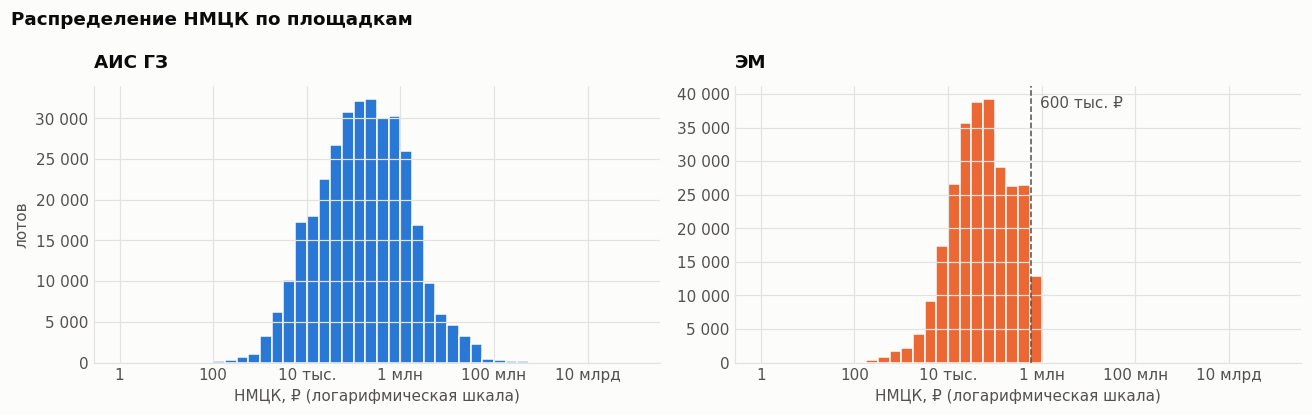

Доля лотов ЭМ с НМЦК ≤ 600 тыс. ₽: 99.9%


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
bins = np.arange(0, 11.01, 0.25)
for ax, p in zip(axes, ['АИС ГЗ', 'ЭМ']):
    v = np.log10(n.loc[(n.is_eshop_or_aisgz == p) & (n.price > 0), 'price'])
    ax.hist(v, bins=bins, color=PLAT_COLOR[p], edgecolor=SURF, linewidth=1)
    ax.set_title(p); ax.set_xlabel('НМЦК, ₽ (логарифмическая шкала)')
    ax.set_xticks(range(0, 12, 2)); ax.set_xticklabels(['1', '100', '10 тыс.', '1 млн', '100 млн', '10 млрд'])
    thousands(ax)
axes[0].set_ylabel('лотов')
axes[1].axvline(np.log10(6e5), color=INK2, lw=1, ls='--')
axes[1].annotate('600 тыс. ₽', (np.log10(6e5), axes[1].get_ylim()[1] * 0.92), xytext=(6, 0), textcoords='offset points', color=INK2)
fig.suptitle('Распределение НМЦК по площадкам', x=0.01, ha='left', fontweight='bold', color=INK)
plt.tight_layout(); plt.show()
print('Доля лотов ЭМ с НМЦК ≤ 600 тыс. ₽:', pct((n.loc[n.is_eshop_or_aisgz == 'ЭМ', 'price'] <= 6e5).mean()))

### 2.2 Признак МСП, реестровый номер, текст предмета

In [10]:
display(pd.crosstab(n.is_eshop_or_aisgz, n.is_smp, normalize='index').round(3))

r = n.reqnum.dropna()
print('Заполнен reqnum по площадкам:'); display(n.groupby('is_eshop_or_aisgz').reqnum.apply(lambda s: s.notna().mean()).round(3))
print('Длина reqnum:', r.str.len().value_counts().to_dict())
# Номер извещения ЕИС: 11 цифр кода размещающей организации + 2 цифры года + 6 цифр порядкового номера
rq_year = '20' + r.str[11:13]
print('Год в reqnum совпадает с годом публикации:', pct((rq_year == n.loc[r.index, 'publish_date'].str[:4]).mean()))
print('Первые 4 цифры (тип организации):', r.str[:4].value_counts().head(6).to_dict())

is_smp,false,true
is_eshop_or_aisgz,,
АИС ГЗ,0.549,0.451
ЭМ,1.000,0.000


Заполнен reqnum по площадкам:


is_eshop_or_aisgz
АИС ГЗ    0.696
ЭМ        0.000
Name: reqnum, dtype: float64

Длина reqnum: {19: 231513}


Год в reqnum совпадает с годом публикации: 99.9%
Первые 4 цифры (тип организации): {'0372': 213702, '0172': 16414, '0872': 964, '9800': 196, '0572': 111, '0672': 64}


In [11]:
print('procedure_name == subject:', pct((n.procedure_name == n.subject).mean()))
print('Длина subject:', n.subject.str.len().describe(percentiles=[.5, .9, .99]).round(0).to_dict())

NOISE = {
    '«для нужд…»': r'нужд',
    'год («в 2024 году»)': r'20\d\d',
    'район': r'район',
    'тип учреждения (ГБОУ, ГБУЗ…)': r'ГБОУ|ГБДОУ|ГБУЗ|ГБУ|ГКУ|ГБПОУ|СПб ГБ',
    'Санкт-Петербург': r'Санкт-Петербург',
    'номер («№ 622»)': r'№\s*\d+',
    'адрес («по адресу»)': r'по адрес',
    'ссылка на 44-ФЗ': r'44-ФЗ|ст\.\s*93',
}
noise = pd.DataFrame({k: [n.subject.str.contains(v, regex=True, case=False).mean()] for k, v in NOISE.items()}, index=['доля предметов']).T
noise['доля предметов'] = noise['доля предметов'].map(pct)
noise

procedure_name == subject: 97.9%


Длина subject: {'count': 604452.0, 'mean': 108.0, 'std': 81.0, 'min': 1.0, '50%': 89.0, '90%': 213.0, '99%': 376.0, 'max': 1926.0}


,доля предметов
«для нужд…»,19.3%
год («в 2024 году»),34.1%
район,18.7%
"тип учреждения (ГБОУ, ГБУЗ…)",27.1%
Санкт-Петербург,24.3%
номер («№ 622»),24.7%
адрес («по адресу»),6.1%
ссылка на 44-ФЗ,0.4%


In [12]:
n.sample(12, random_state=11)[['is_eshop_or_aisgz', 'price', 'subject']]

,is_eshop_or_aisgz,price,subject
452943,ЭМ,55191.50,Поставка хозяйственных товаров
409961,ЭМ,32375.00,"Оказание услуг по разработке дизайн-макетов, изготовлению и поставке широкоформатной рекламной продукции (постеры) д..."
149100,АИС ГЗ,879149.54,Поставка лекарственных средств - 53.1
392578,АИС ГЗ,33000.00,Оказание услуг по размещению рекламы о колледже в газете «Деловая перспектива» для СПб ГБПОУ«К...
554670,АИС ГЗ,13227.84,Поставка лекарственных препаратов (МНН АЛЛЕРГЕН ТУБЕРКУЛЕЗНЫЙ РЕКОМБИНАНТНЫЙ В СТАНДАРТНОМ РАЗВЕДЕНИИ) нужд СПб ГБУЗ...
530744,АИС ГЗ,5350.00,Обучению по программе повышения квалификации «Создание безопасной производственной среды на предприятии социального ...
74785,АИС ГЗ,45905.67,"Поставка хозяйственных товаров (мыло, освежитель, чистящие средства)"
544447,ЭМ,44331.25,Выполнение работ по ремонту наружных стыков стеновых панелей здания
577956,ЭМ,125378.00,Оказание услуг по техническому обслуживанию систем вентиляции в 2026-2027 г
436652,ЭМ,14721.72,Выполнение работ по обследованию нежилого помещения и изготовление по результатам работ следующих документов: технич...


### 2.3 Заказчики

In [13]:
print('Нет ИНН заказчика:', fmt(n.customer_inn.isna().sum()), '| по площадкам:', n.groupby('is_eshop_or_aisgz').customer_inn.apply(lambda s: s.isna().sum()).to_dict())
print('Уникальных заказчиков:', fmt(n.customer_inn.nunique()))
print('Регион по первым цифрам ИНН:', n.customer_inn.str[:2].value_counts().head(5).to_dict())
per_cust = n.groupby('customer_inn').size()
print('Лотов на заказчика:', per_cust.describe(percentiles=[.1, .5, .9, .99]).round(0).to_dict())
print('КПП заказчика (78XX — код налоговой инспекции, по сути район):')
n.customer_kpp.str[:4].value_counts().head(12).to_frame('лотов').T

Нет ИНН заказчика: 8 449 | по площадкам: {'АИС ГЗ': 4648, 'ЭМ': 3801}
Уникальных заказчиков: 2 785


Регион по первым цифрам ИНН: {'78': 592474, '47': 3400, '77': 129}
Лотов на заказчика: {'count': 2785.0, 'mean': 214.0, 'std': 290.0, 'min': 2.0, '10%': 60.0, '50%': 142.0, '90%': 391.0, '99%': 1522.0, 'max': 4537.0}
КПП заказчика (78XX — код налоговой инспекции, по сути район):


customer_kpp,7802,7810,7807,7814,7804,7811,7842,7816,7806,7805,7843,7813
лотов,49336,43224,40467,39749,35158,33020,32914,31786,31575,30126,30044,29944


## 3. ТРУ (позиции лота)

Строка = позиция закупки: название товара, работы или услуги и код ОКПД2.

In [14]:
profile(tru)

,пропусков,"пропусков, %",уникальных,длина мин,длина медиана,длина макс,пример
колонка,,,,,,,
lot_id,0,0.00,604436,7.0,7.0,7.0,4257576
product_name,113,0.00,1109611,2.0,41.0,1987.0,Услуги связи
okpd2_code,238,0.01,8453,2.0,12.0,13.0,61.10.11.110


In [15]:
print('Полных дублей строк:', fmt(tru.duplicated().sum()), '| дублей (lot_id, product_name):', fmt(tru.duplicated(['lot_id', 'product_name']).sum()))
per_lot = tru.groupby('lot_id').size()
print('Позиций на лот:', per_lot.describe(percentiles=[.5, .75, .9, .99]).round(1).to_dict())
print('Лотов с > 100 позициями:', fmt((per_lot > 100).sum()))
print('Лоты ТРУ без извещения:', (~tru.lot_id.isin(notices.lot_id)).sum(),
      '| извещения без ТРУ:', (~notices.lot_id.isin(tru.lot_id)).sum())

FORMATS = [('XX.XX.XX.XXX (категория)', r'\d{2}\.\d{2}\.\d{2}\.\d{3}'), ('XX.XX.XX (вид)', r'\d{2}\.\d{2}\.\d{2}'),
           ('XX.XX.X (подгруппа)', r'\d{2}\.\d{2}\.\d'), ('XX.XX (группа)', r'\d{2}\.\d{2}'),
           ('XX.X (подкласс)', r'\d{2}\.\d'), ('XX (класс)', r'\d{2}')]
code_s = tru.okpd2_code.fillna('')
kind = pd.Series('другое', index=tru.index)
for name, rx in reversed(FORMATS):
    kind[code_s.str.fullmatch(rx)] = name
kind[tru.okpd2_code.isna()] = 'пусто'
display(kind.value_counts().to_frame('позиций'))
print('Нестандартные коды:', tru.okpd2_code[kind == 'другое'].tolist())

Полных дублей строк: 412 077 | дублей (lot_id, product_name): 415 059


Позиций на лот: {'count': 604436.0, 'mean': 4.9, 'std': 29.5, 'min': 1.0, '50%': 1.0, '75%': 4.0, '90%': 10.0, '99%': 50.0, 'max': 7011.0}
Лотов с > 100 позициями: 1 364


Лоты ТРУ без извещения: 0 | извещения без ТРУ: 16


,позиций
XX.XX.XX.XXX (категория),2816400
XX.XX (группа),74610
XX.XX.X (подгруппа),46068
XX.XX.XX (вид),33780
XX.X (подкласс),514
пусто,238
XX (класс),39
другое,2


Нестандартные коды: ['13.99.19.11', '25.71.11.1200']


Классов в данных: 83 | без названия в справочнике: []


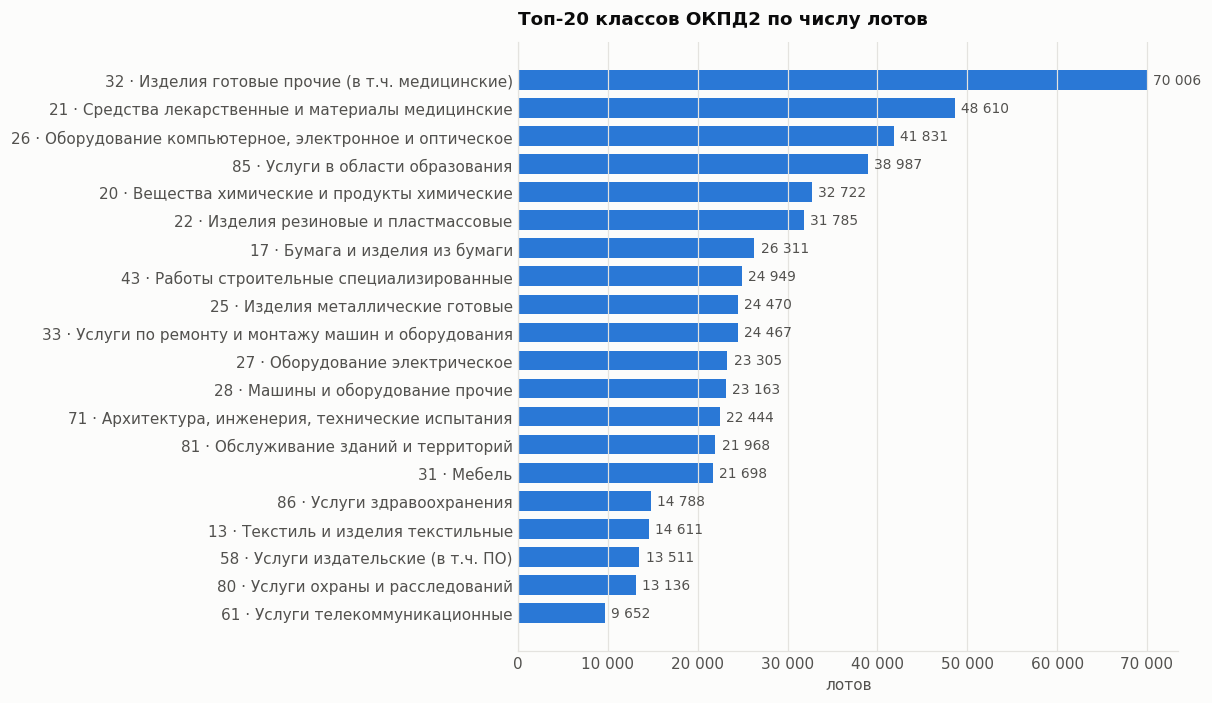

In [16]:
OKPD2_CLASSES = {
 '05': 'Уголь', '06': 'Нефть и газ природный', '07': 'Руды металлические', '12': 'Изделия табачные',
 '99': 'Услуги экстерриториальных организаций',
 '01': 'Продукция сельского хозяйства', '02': 'Продукция лесоводства', '03': 'Рыба и продукция рыболовства',
 '08': 'Продукция горнодобывающих производств прочая', '10': 'Продукты пищевые', '11': 'Напитки',
 '13': 'Текстиль и изделия текстильные', '14': 'Одежда', '15': 'Кожа и изделия из кожи', '16': 'Древесина и изделия из дерева',
 '17': 'Бумага и изделия из бумаги', '18': 'Услуги печатные и копирование', '19': 'Кокс и нефтепродукты',
 '20': 'Вещества химические и продукты химические', '21': 'Средства лекарственные и материалы медицинские',
 '22': 'Изделия резиновые и пластмассовые', '23': 'Продукты минеральные неметаллические прочие', '24': 'Металлы основные',
 '25': 'Изделия металлические готовые', '26': 'Оборудование компьютерное, электронное и оптическое',
 '27': 'Оборудование электрическое', '28': 'Машины и оборудование прочие', '29': 'Средства автотранспортные',
 '30': 'Средства транспортные прочие', '31': 'Мебель', '32': 'Изделия готовые прочие (в т.ч. медицинские)',
 '33': 'Услуги по ремонту и монтажу машин и оборудования', '35': 'Электроэнергия, газ, пар',
 '36': 'Вода природная; водоподготовка', '37': 'Услуги по водоотведению', '38': 'Услуги по сбору и обработке отходов',
 '39': 'Услуги по рекультивации', '41': 'Здания и работы по возведению зданий', '42': 'Сооружения и строительные работы',
 '43': 'Работы строительные специализированные', '45': 'Торговля и ремонт автотранспортных средств',
 '46': 'Услуги по оптовой торговле', '47': 'Услуги по розничной торговле', '49': 'Услуги сухопутного транспорта',
 '50': 'Услуги водного транспорта', '51': 'Услуги воздушного транспорта', '52': 'Услуги складского хозяйства',
 '53': 'Услуги почтовой и курьерской связи', '55': 'Услуги по предоставлению мест для проживания',
 '56': 'Услуги общественного питания', '58': 'Услуги издательские (в т.ч. ПО)', '59': 'Кино- и видеопроизводство',
 '60': 'Услуги в области вещания', '61': 'Услуги телекоммуникационные', '62': 'Разработка ПО и консультирование',
 '63': 'Услуги в области информационных технологий', '64': 'Услуги финансовые', '65': 'Услуги страховые',
 '66': 'Услуги вспомогательные финансовые', '68': 'Услуги по операциям с недвижимостью',
 '69': 'Услуги юридические и бухгалтерские', '70': 'Консультирование по вопросам управления',
 '71': 'Архитектура, инженерия, технические испытания', '72': 'Научные исследования и разработки',
 '73': 'Реклама и исследование рынка', '74': 'Услуги профессиональные прочие', '75': 'Услуги ветеринарные',
 '77': 'Аренда и лизинг', '78': 'Услуги по трудоустройству', '79': 'Туристические услуги',
 '80': 'Услуги охраны и расследований', '81': 'Обслуживание зданий и территорий', '82': 'Административно-хозяйственные услуги',
 '84': 'Услуги государственного управления', '85': 'Услуги в области образования', '86': 'Услуги здравоохранения',
 '87': 'Уход с обеспечением проживания', '88': 'Социальные услуги без проживания', '90': 'Творчество, искусство, развлечения',
 '91': 'Библиотеки, архивы, музеи', '93': 'Спорт, отдых и развлечения', '94': 'Услуги общественных организаций',
 '95': 'Ремонт компьютеров и предметов быта', '96': 'Услуги персональные прочие',
}
cls = tru.assign(cls=tru.okpd2_code.str[:2]).dropna(subset=['cls'])
by_cls = cls.groupby('cls').agg(позиций=('lot_id', 'size'), лотов=('lot_id', 'nunique'))
by_cls['название'] = by_cls.index.map(OKPD2_CLASSES).fillna('—')
print('Классов в данных:', len(by_cls), '| без названия в справочнике:', by_cls.index[by_cls['название'] == '—'].tolist())
top = by_cls.sort_values('лотов', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 6.5))
labels = [f'{c} · {name}' for c, name in zip(top.index, top['название'])]
ax.barh(labels[::-1], top['лотов'][::-1], color=C_BLUE, height=0.7)
for i, v in enumerate(top['лотов'][::-1]):
    ax.annotate(fmt(v), (v, i), xytext=(4, 0), textcoords='offset points', va='center', color=INK2, fontsize=9)
ax.set_title('Топ-20 классов ОКПД2 по числу лотов'); ax.set_xlabel('лотов'); thousands(ax, 'x')
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

In [17]:
cls_per_lot = cls.groupby('lot_id').cls.nunique()
print('Лотов с позициями из нескольких классов ОКПД2:', pct((cls_per_lot > 1).mean()))
print('Коротких названий (< 4 символов):', fmt((tru.product_name.str.strip().str.len() < 4).sum()),
      tru.product_name[tru.product_name.str.strip().str.len() < 4].str.strip().value_counts().head(8).to_dict())
tru.sample(12, random_state=5)

Лотов с позициями из нескольких классов ОКПД2: 8.8%


Коротких названий (< 4 символов): 2 853 {'Рис': 721, 'Ерш': 363, 'ЭКГ': 228, 'Таз': 191, 'Мяч': 124, 'Пуф': 92, 'Нож': 76, 'МФУ': 69}


,lot_id,product_name,okpd2_code
266788,5065554,Санитарно-эпидемиологическая экспертиза по результатам лабораторных исследований пищевых продуктов по микробиологич...,71.20.11.190
1978552,5681346,Изготовление стендовой продукции (кубы большие),18.12.19.190
1986489,5683669,Чистящее средство для ковров,20.41.32.119
2500157,5875319,Резистор отопителя для Volkswagen Caddy (дизельный двигатель),45.20.21.519
1711142,5592866,ЙОПРОМИД,21.20.23.112
2028358,5696695,Вал ЗМ МТЗ-320 БЗТДиА 220-2402037 - Артикул (каталожный номер) или эквивалент,29.32.30.390
2505624,5877268,Наконечники для автоматического иммунохимического анализатора,22.29.29.190
734058,5221904,"Пожарный 30 см, (1 шт)",32.40.39.290
2363424,5816477,Субпродукты пищевые говяжьи замороженные тип 1,10.11.31.140
12961,4966805,Отбор проб воздуха рабочей зоны до 6 показателей на 1 рабочем месте,86.90.15.000


## 4. Поставщики (участники лотов)

In [18]:
profile(sup)

,пропусков,"пропусков, %",уникальных,длина мин,длина медиана,длина макс,пример
колонка,,,,,,,
lot_id,0,0.00,550173,7.0,7.0,7.0,4257576
supplier_inn,0,0.00,44199,9.0,10.0,15.0,7707049388
supplier_kpp,191361,18.94,1134,9.0,9.0,9.0,784201001
is_winner,0,0.00,2,4.0,4.0,5.0,true


In [19]:
print('Дублей (lot_id, supplier_inn):', sup.duplicated(['lot_id', 'supplier_inn']).sum())
print('Длина ИНН:', sup.supplier_inn.str.len().value_counts().to_dict())
print('Пустой КПП по типу (10 знаков — юрлицо, 12 — ИП):',
      sup.groupby(sup.supplier_inn.str.len()).supplier_kpp.apply(lambda s: round(s.isna().mean(), 3)).to_dict())
print('Лоты поставщиков без извещения:', (~sup.lot_id.isin(notices.lot_id)).sum())

sp = sup.merge(n[['lot_id', 'is_eshop_or_aisgz', 'month', 'date', 'customer_inn']], on='lot_id', how='left')
sp['win'] = sp.is_winner == 'true'
lot_stat = sp.groupby('lot_id').agg(platform=('is_eshop_or_aisgz', 'first'), n_part=('supplier_inn', 'size'),
                                    n_win=('win', 'sum'))
print('Победителей на лот:')
display(pd.crosstab(lot_stat.platform, lot_stat.n_win.clip(upper=2).map({0: '0', 1: '1', 2: '2+'}), normalize='index').round(3))

Дублей (lot_id, supplier_inn): 31


Длина ИНН: {10: 706464, 12: 303638, 11: 27, 9: 5, 14: 2, 15: 1, 13: 1}


Пустой КПП по типу (10 знаков — юрлицо, 12 — ИП): {9: 0.8, 10: 0.0, 11: 0.0, 12: 0.63, 13: 1.0, 14: 0.0, 15: 1.0}


Лоты поставщиков без извещения: 0


Победителей на лот:


n_win,0,1,2+
platform,,,
АИС ГЗ,0.000,0.999,0.001
ЭМ,0.026,0.974,0.000


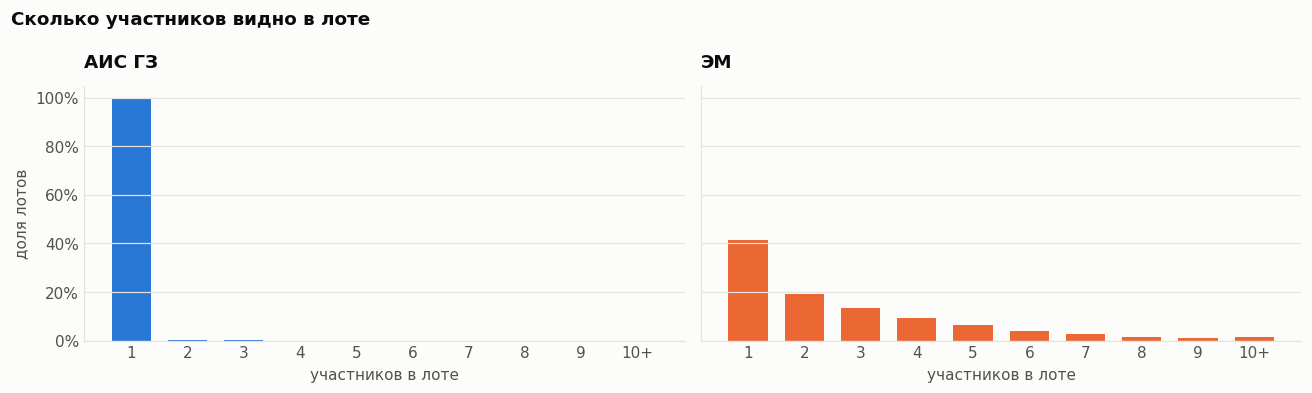

{'АИС ГЗ': 1.0, 'ЭМ': 2.69}


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for ax, p in zip(axes, ['АИС ГЗ', 'ЭМ']):
    v = lot_stat.loc[lot_stat.platform == p, 'n_part'].clip(upper=10).value_counts(normalize=True).sort_index()
    ax.bar([str(i) if i < 10 else '10+' for i in v.index], v.values, color=PLAT_COLOR[p], width=0.7)
    ax.set_title(p); ax.set_xlabel('участников в лоте')
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0)); ax.grid(axis='x', visible=False)
axes[0].set_ylabel('доля лотов')
fig.suptitle('Сколько участников видно в лоте', x=0.01, ha='left', fontweight='bold', color=INK)
plt.tight_layout(); plt.show()
print(lot_stat.groupby('platform').n_part.mean().round(2).to_dict())

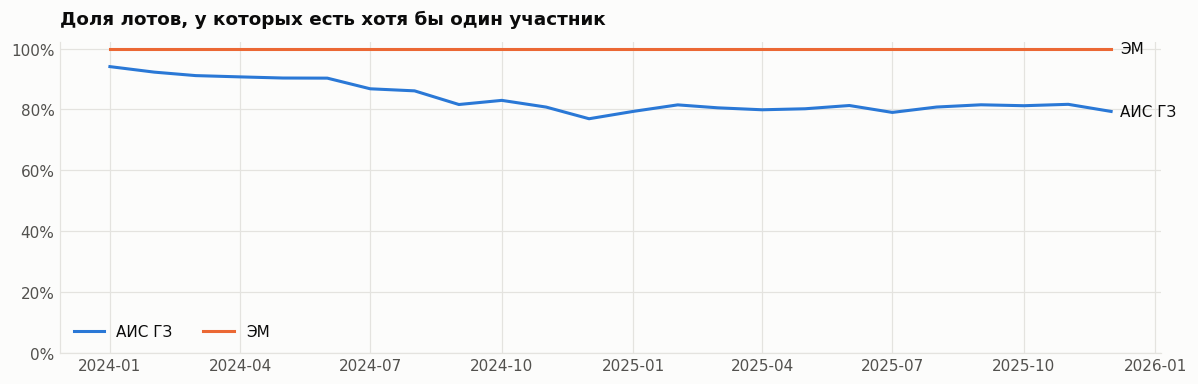

is_eshop_or_aisgz,АИС ГЗ,ЭМ
month,,
2025-09,0.815,1.0
2025-10,0.812,1.0
2025-11,0.817,1.0
2025-12,0.793,1.0


In [21]:
cov = n.assign(has_sup=n.lot_id.isin(sup.lot_id)).groupby(['month', 'is_eshop_or_aisgz']).has_sup.mean().unstack()
x = cov.index.to_timestamp()
fig, ax = plt.subplots(figsize=(11, 3.6))
for p in ['АИС ГЗ', 'ЭМ']:
    ax.plot(x, cov[p], color=PLAT_COLOR[p], label=p)
    ax.annotate(p, (x[-1], cov[p].iloc[-1]), xytext=(6, 0), textcoords='offset points', va='center', color=INK)
ax.set_title('Доля лотов, у которых есть хотя бы один участник')
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0)); ax.set_ylim(0, 1.02)
ax.legend(loc='lower left', ncol=2)
plt.tight_layout(); plt.show()
display(cov.tail(4).round(3))

In [22]:
REGIONS = {'78': 'Санкт-Петербург', '77': 'Москва', '97': 'Москва', '47': 'Ленинградская обл.', '50': 'Московская обл.',
           '66': 'Свердловская обл.', '74': 'Челябинская обл.', '23': 'Краснодарский край', '52': 'Нижегородская обл.',
           '54': 'Новосибирская обл.', '16': 'Татарстан', '60': 'Псковская обл.', '10': 'Карелия', '53': 'Новгородская обл.',
           '76': 'Ярославская обл.', '63': 'Самарская обл.', '61': 'Ростовская обл.', '39': 'Калининградская обл.'}
reg = sup.drop_duplicates('supplier_inn').supplier_inn.str[:2].value_counts(normalize=True).head(10).to_frame('доля поставщиков')
reg['регион'] = reg.index.map(REGIONS).fillna('—')
reg['доля поставщиков'] = reg['доля поставщиков'].map(pct)
reg

,доля поставщиков,регион
supplier_inn,,
78,52.8%,Санкт-Петербург
77,6.7%,Москва
47,5.3%,Ленинградская обл.
50,2.2%,Московская обл.
97,1.7%,Москва
66,1.7%,Свердловская обл.
74,1.1%,Челябинская обл.
23,1.1%,Краснодарский край
52,1.0%,Нижегородская обл.


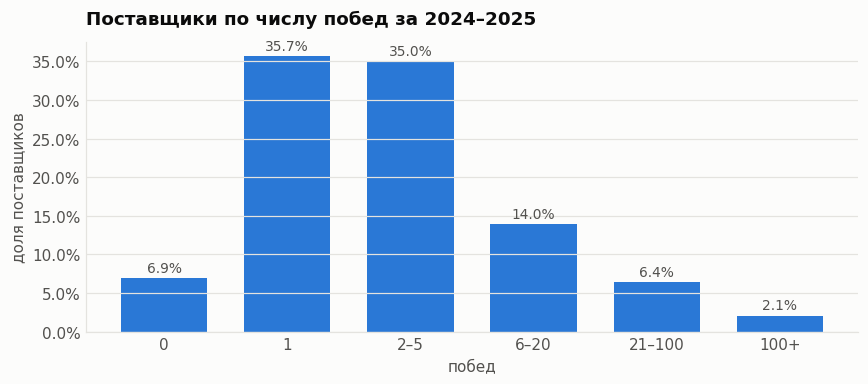

Поставщиков: 44 199 | топ-1% поставщиков забирают 42.7% побед


In [23]:
wins = sup[sup.is_winner == 'true'].supplier_inn.value_counts()
all_inn = sup.supplier_inn.unique()
w_all = pd.Series(0, index=all_inn).add(wins, fill_value=0)
buckets = pd.cut(w_all, [-1, 0, 1, 5, 20, 100, np.inf], labels=['0', '1', '2–5', '6–20', '21–100', '100+']).value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(buckets.index.astype(str), buckets.values, color=C_BLUE, width=0.7)
for i, v in enumerate(buckets.values):
    ax.annotate(pct(v), (i, v), xytext=(0, 4), textcoords='offset points', ha='center', color=INK2, fontsize=9)
ax.set_title('Поставщики по числу побед за 2024–2025'); ax.set_xlabel('побед'); ax.set_ylabel('доля поставщиков')
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0)); ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()
print('Поставщиков:', fmt(len(all_inn)), '| топ-1% поставщиков забирают', pct(wins.head(int(len(all_inn) * .01)).sum() / wins.sum()), 'побед')

### 4.1 Повторяемость побед

Насколько победитель предсказуем по истории? Для победителей 2025 года проверяем, что было известно о них до даты лота. Эти доли задают ожидания от бейзлайнов и показывают долю «холодного старта».

In [24]:
lot_cls = (cls.groupby(['lot_id', 'cls']).size().reset_index(name='k')
              .sort_values(['lot_id', 'k'], ascending=[True, False]).drop_duplicates('lot_id')[['lot_id', 'cls']])
w = (sp[sp.is_winner == 'true'].merge(lot_cls, on='lot_id', how='left')
       .dropna(subset=['customer_inn']).sort_values(['date', 'lot_id']))
w['seen_anywhere'] = w.groupby('supplier_inn').cumcount() > 0
w['seen_class'] = w.groupby(['supplier_inn', 'cls']).cumcount() > 0
w['seen_customer'] = w.groupby(['supplier_inn', 'customer_inn']).cumcount() > 0
w['seen_customer_class'] = w.groupby(['supplier_inn', 'customer_inn', 'cls']).cumcount() > 0
w25 = w[w.date.dt.year == 2025]
rep = w25.groupby('is_eshop_or_aisgz')[['seen_customer_class', 'seen_customer', 'seen_class', 'seen_anywhere']].mean()
rep.columns = ['выигрывал у этого заказчика в этом классе', 'выигрывал у этого заказчика', 'выигрывал в этом классе', 'выигрывал хоть что-то']
rep.T.map(pct)

is_eshop_or_aisgz,АИС ГЗ,ЭМ
выигрывал у этого заказчика в этом классе,50.5%,46.5%
выигрывал у этого заказчика,57.5%,61.9%
выигрывал в этом классе,88.8%,93.2%
выигрывал хоть что-то,93.3%,98.1%


## 5. Предобработка

Шаги:
1. ИНН: проверка контрольной суммы, восстановление потерянного ведущего нуля.
2. Извещения: типы, площадка, НМЦК (ноль → пропуск, логарифм с обрезкой выбросов), разбор `reqnum`, район заказчика.
3. Текст: удаление шаблонов (заказчик, год, период, номер, адрес, ссылки на закон), нормализация, лемматизация.
4. ТРУ: схлопывание дублей с подсчётом кратности, нормализация ОКПД2 и разложение по уровням иерархии.
5. Поставщики: чистые ИНН, тип лица, регион, дедупликация.
6. Таблица лотов: агрегаты по позициям и участникам, признак пригодности для обучения, сплит по времени.

### 5.1 ИНН

In [25]:
K10 = [2, 4, 10, 3, 5, 9, 4, 6, 8]
K11 = [7, 2, 4, 10, 3, 5, 9, 4, 6, 8]
K12 = [3, 7, 2, 4, 10, 3, 5, 9, 4, 6, 8]

def inn_valid(s):
    if not isinstance(s, str) or not s.isdigit():
        return False
    d = [int(c) for c in s]
    if len(s) == 10:
        return sum(a * b for a, b in zip(K10, d)) % 11 % 10 == d[9]
    if len(s) == 12:
        return (sum(a * b for a, b in zip(K11, d)) % 11 % 10 == d[10]
                and sum(a * b for a, b in zip(K12, d)) % 11 % 10 == d[11])
    return False

def fix_inn(s):
    # Возвращает (ИНН, статус): valid / fixed_zero (восстановлен ведущий ноль) / invalid
    if not isinstance(s, str):
        return None, 'missing'
    s = re.sub(r'\D', '', s)
    if inn_valid(s):
        return s, 'valid'
    if len(s) in (9, 11) and inn_valid('0' + s):
        return '0' + s, 'fixed_zero'
    return s, 'invalid'

def clean_inn(series):
    u = series.dropna().unique()
    mapping = {x: fix_inn(x) for x in u}
    inn = series.map(lambda x: mapping[x][0] if isinstance(x, str) else None)
    status = series.map(lambda x: mapping[x][1] if isinstance(x, str) else 'missing')
    return inn, status

assert inn_valid('7707083893') and inn_valid('500100732259') and not inn_valid('7707083894')

sup_inn, sup_inn_status = clean_inn(sup.supplier_inn)
cust_inn, cust_inn_status = clean_inn(notices.customer_inn)
print('ИНН поставщиков:', sup_inn_status.value_counts().to_dict())
print('ИНН заказчиков:', cust_inn_status.value_counts().to_dict())
print('Примеры невалидных ИНН поставщиков:', sup.supplier_inn[sup_inn_status == 'invalid'].unique()[:15].tolist())

ИНН поставщиков: {'valid': 1010007, 'invalid': 131}
ИНН заказчиков: {'valid': 596003, 'missing': 8449}
Примеры невалидных ИНН поставщиков: ['UJ65120100', '7817120232', '612103239820', '782606230600', '322169000196810', '102382656', '783800956607', '102385762', '714084858900', '780161125542', '780207835812', '000000424277', '100604414427', '784002023490', '0300834359']


### 5.2 Извещения

In [26]:
lots = pd.DataFrame({
    'lot_id': notices.lot_id.astype('int64'),
    'procedure_id': notices.procedure_id.astype('int64'),
    'publish_date': pd.to_datetime(notices.publish_date),
    'platform': notices.is_eshop_or_aisgz.map({'АИС ГЗ': 'AISGZ', 'ЭМ': 'EM'}),
    'is_smp': notices.is_smp.map({'true': True, 'false': False}),
    'start_price': pd.to_numeric(notices.start_price, errors='coerce'),
    'reqnum': notices.reqnum,
    'customer_inn': cust_inn,
    'customer_inn_status': cust_inn_status,
    'customer_kpp': notices.customer_kpp,
    'procedure_name': notices.procedure_name.str.strip(),
    'subject': notices.subject.str.strip(),
})
assert lots.platform.notna().all() and lots.is_smp.notna().all()

lots.loc[lots.start_price <= 0, 'start_price'] = np.nan
cap = lots.groupby('platform').start_price.transform(lambda s: s.quantile(0.999))
lots['price_outlier'] = lots.start_price > cap
lots['price_log'] = np.log1p(lots.start_price.clip(upper=cap))

lots['has_reqnum'] = lots.reqnum.notna()
lots['reqnum_org'] = lots.reqnum.str[:11]
lots['customer_region'] = lots.customer_inn.str[:2]
lots['customer_district'] = lots.customer_kpp.str[:4]
lots['name_differs'] = lots.procedure_name != lots.subject
lots['year_month'] = lots.publish_date.dt.to_period('M').astype(str)

print('НМЦК: пропусков', lots.start_price.isna().sum(), '| выбросов (> p99.9 площадки)', lots.price_outlier.sum())
lots.head(3)

НМЦК: пропусков 24 | выбросов (> p99.9 площадки) 490


,lot_id,procedure_id,publish_date,platform,is_smp,start_price,reqnum,customer_inn,customer_inn_status,customer_kpp,procedure_name,subject,price_outlier,price_log,has_reqnum,reqnum_org,customer_region,customer_district,name_differs,year_month
0,2077538,1841706,2024-07-11,AISGZ,False,530000.00,NaN,7804105239,valid,780401001,Преподавательские услуги (п.33 ч.1 ст.93 Федерального закона №44-ФЗ),Преподавательские услуги (п.33 ч.1 ст.93 Федерального закона №44-ФЗ),False,13.180634,False,NaN,78,7804,False,2024-07
1,4257576,4021762,2024-01-18,AISGZ,False,2835.54,NaN,7807022750,valid,780701001,Оказание услуг связи,Оказание услуг связи,False,7.950340,False,NaN,78,7807,False,2024-01
2,4633163,4397352,2024-12-06,AISGZ,False,13500.00,NaN,7805149197,valid,780501001,"Приобретение неисключительных прав использования программного комплекса ""СБиС""","Приобретение неисключительных прав использования программного комплекса ""СБиС""",False,9.510519,False,NaN,78,7805,False,2024-12


### 5.3 Очистка текста

Из текста убираем то, что описывает заказчика и период, а не предмет закупки: «для нужд…», названия учреждений, районы, годы, даты, номера, адреса, ссылки на 44-ФЗ. Получаем две версии:

- `*_clean` — нормализованный текст для эмбеддингов (порядок слов сохранён);
- `*_lemma` — леммы без стоп-слов для TF-IDF и поиска по словам.

In [27]:
MONTH = r'(?:январ\w*|феврал\w*|март\w*|апрел\w*|ма[йяе]\b|июн\w*|июл\w*|август\w*|сентябр\w*|октябр\w*|ноябр\w*|декабр\w*)'
CUSTOMER_START = (r'(?:санкт-петербургск|спб\b|сп?б?\s*гб|гб[а-я]*\b|гк[а-я]*\b|государственн|муниципальн|учреждени'
                  r'|школ|детск|дошкольн|поликлиник|больниц|колледж|лице[йя]|гимнази|библиотек|театр|музе|администрац|комитет)')
PATTERNS = [
    (r'[«»“”„"\']', ' '),
    (r'\s(?:для\s+)?(?:обеспечения\s+)?нужд\b.*$', ' '),                        # «для нужд …» до конца
    (r'\sдля\s+' + CUSTOMER_START + r'.*$', ' '),                                 # «для ГБОУ …» до конца
    (r'\s(?:расположенн\w+\s+)?по\s+адрес\w*.*$', ' '),                           # адрес до конца
    (r'\s(?:сп?б\s+)?(?:гбоу|гбдоу|гбуз|гбу|гку|гкоу|гбпоу|гбук|гау|гуп|гбоуди|фгку|фгбу|фгуп)\b.*$', ' '),  # «… СПб ГБУЗ …» до конца
    (r'\s(?:в|во)?\s*(?:федеральн\w+\s+|санкт-петербургск\w+\s+)?государственн\w+\s+(?:бюджетн|казенн|автономн|унитарн)\w*.*$', ' '),
    (r'\(?\bлот\s*№?\s*\d+\)?', ' '),
    (r'\(?\s*п\.?\s*\d+\s*ч\.?\s*\d+\s*ст\.?\s*\d+[^)]*\)?', ' '),                 # (п.33 ч.1 ст.93 …)
    (r'федеральн\w+\s+закон\w*|\d+\s*-\s*фз', ' '),
    (r'\bс\s+\d{1,2}\.\d{1,2}(?:\.\d{2,4})?\s*(?:г\.?)?\s*(?:по|-|–)\s*\d{1,2}\.\d{1,2}(?:\.\d{2,4})?(?:\s*(?:года?|г\.?)(?![а-я]))?', ' '),
    (r'\b\d{1,2}\.\d{1,2}\.\d{2,4}\b', ' '),
    (r'\b(?:в|на|за|с|по)?\s*' + MONTH + r'(?:\s*[-–]\s*' + MONTH + r')?(?=\W|$)', ' '),
    (r'\b(?:в|на|за)?\s*20\d\d(?:\s*[-–/]\s*(?:20)?\d\d)?(?:\s*(?:год\w*|гг?\.?)(?![а-я]))?', ' '),
    (r'№\s*[\w./-]*\d[\w./-]*', ' '),
    (r'\b(?:сп?б\s+)?(?:гбоу|гбдоу|гбуз|гбу|гку|гкоу|гбпоу|гбук|гау|гуп|гбоуди|гбу\s+до|гбоу\s+до|ддт)\b', ' '),
    (r'\b[а-я]+(?:ого|его)\s+(?:района|р-на)\b', ' '),
    (r'санкт-\s*петербург\w*|\bспб\b|\bг\.\s*', ' '),
    (r'[()\[\]{};:!?]', ' '),
    (r'\s+', ' '),
]
PATTERNS = [(re.compile(p), r) for p, r in PATTERNS]
TAIL_PREP = re.compile(r'(?:\s+(?:в|во|на|для|по|с|со|и|за|к|при|от))+$')  # предлоги, повисшие после обрезки хвоста

def clean_text(s):
    if not isinstance(s, str):
        return ''
    t = s.lower().replace('ё', 'е').replace('\t', ' ').replace('\n', ' ')
    for rx, rep in PATTERNS:
        t = rx.sub(rep, t)
    t = t.strip(' ,.-–;')
    t = TAIL_PREP.sub('', t).strip(' ,.-–;')
    return t if t else s.lower().strip()

examples = lots.subject.sample(14, random_state=3).tolist() + [
    'Преподавательские услуги (п.33 ч.1 ст.93 Федерального закона №44-ФЗ)',
    'Оказание услуг по организации горячего питания для ГБДОУ детский сад № 87 Приморского района Санкт-Петербурга в 2025 году',
    'Оказание услуг по техническому обслуживанию комплексных систем обеспечения безопасности объектов в сентябре - декабре 2024 года',
    'Поставка многофункционального устройства (МФУ) тип 9 для нужд СПб ГБУЗ "Городская поликлиника №48"',
    'Оказание услуг по управлению транспортным средством (Лада Гранта) с 01.01.2026 по 31.03.2026г.',
    'Оказание услуг по организации питания в Государственном бюджетном общеобразовательном учреждении лицей № 101 Выборгского района Санкт-Петербурга в феврале 2024 года.',
    'Оказание услуг по адаптации справочной правовой системы «Консультант Плюс» в СПб ГБУЗ "Городская больница № 40" в 2024 году',
    'Поставка автомобильного бензина АИ -95  для нужд СПб ГБУ «Служба заказчика Пушкинского р-на»',
    'Поставка медицинских изделий №121.25-26 в 2025-2026 годах',
    'Поставка канцелярских товаров в 2025 году (лот 2)',
    'Приобретение жилого помещения (квартиры) в государственную собственность Санкт-Петербурга',
]
pd.DataFrame({'до': examples, 'после': [clean_text(e) for e in examples]})

,до,после
0,Поставка оргтехники для нужд ГБДОУ детский сад № 25 Центрального района СПб.,поставка оргтехники
1,"Оказание услуг по проведению планового технического, метрологического обслуживания, градуировке и поверке газовых хр...","оказание услуг по проведению планового технического, метрологического обслуживания, градуировке и поверке газовых хр..."
2,Оказание услуг по диагностике неисправности сушильной машины,оказание услуг по диагностике неисправности сушильной машины
3,Оказание услуг по проведению производственного контроля на пищеблоке в 2026 году,оказание услуг по проведению производственного контроля на пищеблоке
4,Оказание услуг по организации и проведению тренировочных занятий по футболу в спортивном зале для нужд ГБУ ДО СШОР №...,оказание услуг по организации и проведению тренировочных занятий по футболу в спортивном зале
5,"Поставка хозяйственных товаров для нужд СПб ГБУ ""КЦСОН Выборгского района""",поставка хозяйственных товаров
6,Поставка канцелярских товаров в 2025 году (лот 2),поставка канцелярских товаров
7,Поставка автомобильного бензина АИ -95 для нужд СПб ГБУ «Служба заказчика Пушкинского р-на»,поставка автомобильного бензина аи -95
8,Поставка канцелярских товаров Лот 1,поставка канцелярских товаров
9,Поставка металлических секций для зон ожидания,поставка металлических секций для зон ожидания


In [28]:
t0 = time.time()
u_subj = lots.subject.dropna().unique()
subj_map = {s: clean_text(s) for s in u_subj}
lots['subject_clean'] = lots.subject.map(subj_map).fillna('')

u_names = tru.product_name.dropna().str.strip().unique()
name_map = {s: clean_text(s) for s in u_names}
print(f'Очищено {fmt(len(u_subj))} предметов и {fmt(len(u_names))} названий позиций за {time.time() - t0:.0f} с')
print('Средняя длина предмета: было', round(lots.subject.str.len().mean()), '→ стало', round(lots.subject_clean.str.len().mean()), 'символов')

Очищено 370 942 предметов и 1 063 278 названий позиций за 161 с


Средняя длина предмета: было 108 → стало 73 символов


In [29]:
import pymorphy3
morph = pymorphy3.MorphAnalyzer()
TOKEN = re.compile(r'[а-яa-z0-9]+(?:-[а-яa-z0-9]+)*')
STOP = set('и в во на по для с со к ко о об обо от из за при до под над или а но же ли не ни как что это то '
           'его ее их том тот та те так также т.ч числе том а также иной иных прочие прочих'.split())

t0 = time.time()
tok_counter = Counter()
for txt in list(subj_map.values()) + list(name_map.values()):
    tok_counter.update(TOKEN.findall(txt))
lemma_cache = {}
for tok in tok_counter:
    if re.search('[а-я]', tok) and not re.search(r'\d', tok):
        lemma_cache[tok] = morph.parse(tok)[0].normal_form
    else:
        lemma_cache[tok] = tok
print(f'Уникальных токенов: {fmt(len(tok_counter))}, лемматизация {time.time() - t0:.0f} с')

def lemmatize(txt):
    return ' '.join(l for l in (lemma_cache[t] for t in TOKEN.findall(txt)) if l not in STOP and len(l) > 1)

lemma_subj = {v: lemmatize(v) for v in set(subj_map.values())}
lots['subject_lemma'] = lots.subject_clean.map(lemma_subj).fillna('')
print('Пример:', lots.subject_clean.iloc[3], '→', lots.subject_lemma.iloc[3])

Уникальных токенов: 361 191, лемматизация 65 с


Пример: выполнение работ по техническому комплексному обслуживанию оборудования бассейнов в здании → выполнение работа технический комплексный обслуживание оборудование бассейн здание


### 5.4 ТРУ: дубли и уровни ОКПД2

Иерархия ОКПД2: класс `XX` → подкласс `XX.X` → группа `XX.XX` → подгруппа `XX.XX.X` → вид `XX.XX.XX` → категория `XX.XX.XX.XXX`. Нестандартные коды обрезаются до ближайшего корректного уровня.

In [30]:
t = tru.copy()
t['lot_id'] = t.lot_id.astype('int64')
t['product_name'] = t.product_name.str.strip()
t['okpd2_raw'] = t.okpd2_code.str.strip()

before = len(t)
t = (t.groupby(['lot_id', 'product_name', 'okpd2_raw'], dropna=False, sort=False)
       .size().rename('n_rows').reset_index())
print(f'Строк ТРУ: {fmt(before)} → {fmt(len(t))} после схлопывания дублей (кратность в n_rows)')

VALID = re.compile(r'^\d{2}(?:\.\d(?:\d(?:\.\d(?:\d(?:\.\d{3})?)?)?)?)?$')
PREFIX = re.compile(r'^\d{2}(?:\.\d(?:\d(?:\.\d(?:\d)?)?)?)?')

def norm_code(c):
    if not isinstance(c, str) or not c:
        return None, 'missing'
    if VALID.match(c):
        return c, 'valid'
    m = PREFIX.match(c)
    return (m.group(0), 'truncated') if m else (None, 'invalid')

u_codes = t.okpd2_raw.dropna().unique()
code_map = {c: norm_code(c) for c in u_codes}
t['okpd2'] = t.okpd2_raw.map(lambda c: code_map[c][0] if isinstance(c, str) else None)
t['okpd2_status'] = t.okpd2_raw.map(lambda c: code_map[c][1] if isinstance(c, str) else 'missing')
print('Статус кодов:', t.okpd2_status.value_counts().to_dict())

c = t.okpd2.fillna('')
L = c.str.len()
t['okpd_l1'] = c.str[:2].where(L >= 2)   # класс
t['okpd_l2'] = c.str[:4].where(L >= 4)   # подкласс
t['okpd_l3'] = c.str[:5].where(L >= 5)   # группа
t['okpd_l4'] = c.str[:7].where(L >= 7)   # подгруппа
t['okpd_l5'] = c.str[:8].where(L >= 8)   # вид
t['okpd_l6'] = c.where(L == 12)          # категория
t['okpd_depth'] = t[[f'okpd_l{i}' for i in range(1, 7)]].notna().sum(axis=1)
t['okpd_class_name'] = t.okpd_l1.map(OKPD2_CLASSES)

t['name_clean'] = t.product_name.map(name_map).fillna('')
lemma_name = {v: lemmatize(v) for v in set(name_map.values())}
t['name_lemma'] = t.name_clean.map(lemma_name).fillna('')
print('Глубина кода:', t.okpd_depth.value_counts().sort_index().to_dict())
t.sample(6, random_state=1)[['lot_id', 'product_name', 'name_lemma', 'okpd2', 'okpd_l3', 'okpd_depth', 'n_rows']]

Строк ТРУ: 2 971 651 → 2 549 783 после схлопывания дублей (кратность в n_rows)


Статус кодов: {'valid': 2549563, 'missing': 218, 'truncated': 2}


Глубина кода: {0: 218, 1: 38, 2: 503, 3: 44881, 4: 31563, 5: 26754, 6: 2445826}


,lot_id,product_name,name_lemma,okpd2,okpd_l3,okpd_depth,n_rows
1476803,5594322,Клей для плитки усиленный 25 кг,клей плитка усиленный 25 кг,13.96.17.190,13.96,6,1
1584898,5634802,Удлинитель с сетевым фильтром 5х5м,удлинитель сетевой фильтр 5х5м,27.32.13.190,27.32,6,1
2393071,5988133,Техническое обслуживание АИТП в 2027 году,технический обслуживание аитп,43.22.12.120,43.22,6,1
51959,4990159,Услуги по проведению лабораторных исследований (рыба)(Определение парагемолитического вибриона),услуга проведение лабораторный исследование рыба определение парагемолитический вибрион,86.90.19.110,86.90,6,1
818967,5304599,Комплект восстановления драм-юнита DK-1150 для KYOCERA ECOSYS M2040dn,комплект восстановление драм-юнит dk-1150 kyocera ecosys m2040dn,28.23.25.000,28.23,6,1
1255850,5493310,Аварийное обслуживание инженерных сетей,аварийный обслуживание инженерный сеть,43.22.11.190,43.22,6,1


### 5.5 Поставщики

In [31]:
s = pd.DataFrame({
    'lot_id': sup.lot_id.astype('int64'),
    'supplier_inn': sup_inn,
    'inn_status': sup_inn_status,
    'supplier_kpp': sup.supplier_kpp,
    'is_winner': sup.is_winner.map({'true': True, 'false': False}),
})
assert s.is_winner.notna().all()
dropped = (s.inn_status == 'invalid').sum()
s = s[s.inn_status != 'invalid']
s = (s.sort_values('is_winner', ascending=False)
      .drop_duplicates(['lot_id', 'supplier_inn'])
      .sort_values(['lot_id', 'supplier_inn']).reset_index(drop=True))
s['inn_type'] = np.where(s.supplier_inn.str.len() == 10, 'UL', 'IP')
s['supplier_region'] = s.supplier_inn.str[:2]
orphan = (~s.lot_id.isin(lots.lot_id)).sum()
s = s[s.lot_id.isin(lots.lot_id)]
print('Строк поставщиков без извещения (удалены):', orphan)
s = s.merge(lots[['lot_id', 'platform', 'publish_date', 'customer_inn']], on='lot_id', how='left')
print(f'Удалено строк с невалидным ИНН: {dropped}; осталось {fmt(len(s))} пар «лот × поставщик», {fmt(s.supplier_inn.nunique())} поставщиков')
print('Тип лица:', s.drop_duplicates('supplier_inn').inn_type.value_counts().to_dict())

Строк поставщиков без извещения (удалены): 0


Удалено строк с невалидным ИНН: 131; осталось 1 009 976 пар «лот × поставщик», 44 174 поставщиков
Тип лица: {'IP': 23585, 'UL': 20589}


### 5.6 Таблица лотов: агрегаты, разметка, сплит

Сплит по времени без утечки из будущего:

| Окно | Период | Использование |
|---|---|---|
| `hist` | 08.01.2024 – 31.03.2025 | История для профилей поставщиков |
| `train` | 01.04.2025 – 30.09.2025 | Обучение ранкера (признаки считаются по `hist`) |
| `test` | 01.10.2025 – 31.12.2025 | Оценка (признаки по `hist` + `train`) |

In [32]:
items = t.groupby('lot_id').agg(
    n_positions=('n_rows', 'sum'), n_unique_positions=('product_name', 'size'),
    n_codes=('okpd2', 'nunique'), n_classes=('okpd_l1', 'nunique'), n_groups=('okpd_l3', 'nunique'))
main = (t.dropna(subset=['okpd_l1']).groupby(['lot_id', 'okpd_l1']).n_rows.sum().reset_index()
          .sort_values(['lot_id', 'n_rows'], ascending=[True, False]).drop_duplicates('lot_id')
          .rename(columns={'okpd_l1': 'main_class'})[['lot_id', 'main_class']])
main_g = (t.dropna(subset=['okpd_l3']).groupby(['lot_id', 'okpd_l3']).n_rows.sum().reset_index()
            .sort_values(['lot_id', 'n_rows'], ascending=[True, False]).drop_duplicates('lot_id')
            .rename(columns={'okpd_l3': 'main_group'})[['lot_id', 'main_group']])
parts = s.groupby('lot_id').agg(n_participants=('supplier_inn', 'size'), n_winners=('is_winner', 'sum'))

lots = (lots.merge(items, on='lot_id', how='left').merge(main, on='lot_id', how='left')
            .merge(main_g, on='lot_id', how='left').merge(parts, on='lot_id', how='left'))
for col in ['n_positions', 'n_unique_positions', 'n_codes', 'n_classes', 'n_groups', 'n_participants', 'n_winners']:
    lots[col] = lots[col].fillna(0).astype('int32')
lots['main_class_name'] = lots.main_class.map(OKPD2_CLASSES)
lots['has_tru'] = lots.n_positions > 0
lots['has_suppliers'] = lots.n_participants > 0
lots['train_eligible'] = lots.has_suppliers & (lots.n_winners >= 1) & lots.has_tru

lots['split'] = np.select(
    [lots.publish_date <= '2025-03-31', lots.publish_date <= '2025-09-30'], ['hist', 'train'], 'test')
display(pd.crosstab(lots.split, lots.platform, values=lots.train_eligible, aggfunc='sum', margins=True, margins_name='всего'))
print('Пригодных для обучения лотов:', fmt(lots.train_eligible.sum()), 'из', fmt(len(lots)))

platform,AISGZ,EM,всего
split,,,
hist,176991,159800,336791
test,40173,47977,88150
train,61177,57059,118236
всего,278341,264836,543177


Пригодных для обучения лотов: 543 177 из 604 452


### 5.7 Проверки и сохранение

In [33]:
assert lots.lot_id.is_unique
assert t.n_rows.sum() == len(tru), 'схлопывание ТРУ потеряло строки'
assert s.supplier_inn.map(inn_valid).all()
assert not s.duplicated(['lot_id', 'supplier_inn']).any()
assert set(s.lot_id) <= set(lots.lot_id)
assert (lots.loc[lots.train_eligible, 'n_winners'] >= 1).all()
print('Лотов ТРУ без извещения:', len(set(t.lot_id) - set(lots.lot_id)))
print('Все проверки пройдены')

LOT_COLS = ['lot_id', 'procedure_id', 'publish_date', 'year_month', 'split', 'platform', 'is_smp',
            'start_price', 'price_log', 'price_outlier', 'reqnum', 'has_reqnum', 'reqnum_org',
            'customer_inn', 'customer_inn_status', 'customer_kpp', 'customer_region', 'customer_district',
            'procedure_name', 'subject', 'name_differs', 'subject_clean', 'subject_lemma',
            'n_positions', 'n_unique_positions', 'n_codes', 'n_classes', 'n_groups', 'main_class', 'main_class_name', 'main_group',
            'n_participants', 'n_winners', 'has_tru', 'has_suppliers', 'train_eligible']
TRU_COLS = ['lot_id', 'product_name', 'name_clean', 'name_lemma', 'n_rows', 'okpd2_raw', 'okpd2', 'okpd2_status',
            'okpd_l1', 'okpd_l2', 'okpd_l3', 'okpd_l4', 'okpd_l5', 'okpd_l6', 'okpd_depth', 'okpd_class_name']
SUP_COLS = ['lot_id', 'supplier_inn', 'inn_status', 'inn_type', 'supplier_kpp', 'supplier_region', 'is_winner',
            'platform', 'publish_date', 'customer_inn']

outputs = {
    'lots.parquet': lots[LOT_COLS],
    'tru.parquet': t[TRU_COLS],
    'suppliers.parquet': s[SUP_COLS],
    'okpd2_classes.parquet': pd.DataFrame({'okpd_l1': list(OKPD2_CLASSES), 'name': list(OKPD2_CLASSES.values())}),
}
rows = []
for name, df in outputs.items():
    path = OUT_DIR / name
    df.to_parquet(path, index=False)
    rows.append({'файл': str(path), 'строк': fmt(len(df)), 'колонок': df.shape[1], 'МБ': round(path.stat().st_size / 2**20, 1)})
pd.DataFrame(rows)

Лотов ТРУ без извещения: 0
Все проверки пройдены


,файл,строк,колонок,МБ
0,data\processed\lots.parquet,604 452,36,156.8
1,data\processed\tru.parquet,2 549 783,16,281.9
2,data\processed\suppliers.parquet,1 009 976,10,9.1
3,data\processed\okpd2_classes.parquet,84,2,0.0


## 6. Итоги

### Что в данных

| Таблица | Строк | Ключевое |
|---|---|---|
| Извещения | 604 452 | 1 лот = 1 процедура; 08.01.2024 – 31.12.2025; АИС ГЗ 332 646, ЭМ 271 806 |
| ТРУ | 2 971 651 → 2 549 783 после схлопывания дублей | 8 453 кода ОКПД2, 99% кодов полные (`XX.XX.XX.XXX`) |
| Поставщики | 1 010 138 → 1 009 976 после очистки ИНН | 44 174 поставщика, 53% из СПб |

### Главные наблюдения

1. **Две площадки — два разных режима.** ЭМ: малые закупки (99,9% лотов не дороже 600 тыс. ₽), в среднем 2,7 участника, проигравшие видны. АИС ГЗ: НМЦК до десятков миллиардов, ровно 1 запись на лот (только исполнитель), `reqnum` есть у 70%, закупки у МСП — у 45%. Модель и метрики считаем раздельно по площадкам.
2. **Сильная сезонность.** Пик публикаций в декабре, провал в январе. Сплит по времени это учитывает: в тест попадает пиковый IV квартал 2025.
3. **Разметка полная до конца периода.** В ЭМ участники есть у 100% лотов. В АИС ГЗ доля снижается с 94% в начале 2024 до ≈ 80% к осени 2024 и дальше стабильна до декабря 2025. «Недозаполненного хвоста» в конце периода нет, тестовое окно IV кв. 2025 корректно.
4. **История очень предсказательна.** Среди победителей 2025 года ≈ 50% уже выигрывали у этого же заказчика в этом же классе ОКПД2, ≈ 60% — у этого заказчика, ≈ 90% — в этом классе у кого угодно. Бейзлайн «прошлый победитель у заказчика» будет сильным, модель должна его обходить.
5. **Холодный старт ограничен, но есть.** 2–7% победителей 2025 года раньше не побеждали вообще. Для них нужны контентные признаки и обогащение из реестров.
6. **Концентрация.** Топ-1% поставщиков забирает ≈ 43% побед, при этом 38% поставщиков победили один раз. Длинный хвост.
7. **Текст сильно засорён.** У 19–34% предметов есть «для нужд…», год, номер, тип учреждения или район. После очистки предмет сокращается примерно на треть, остаётся суть закупки.

### Что сделала предобработка

- ИНН: проверка контрольной суммы, восстановление потерянного ведущего нуля; удалена 131 строка поставщиков с невалидным ИНН. 8 449 лотов без ИНН заказчика оставлены.
- НМЦК: нули → пропуск, `price_log` с обрезкой по 99,9-му перцентилю площадки, флаг `price_outlier`.
- Текст: `subject_clean` / `name_clean` для эмбеддингов, `subject_lemma` / `name_lemma` (pymorphy3) для TF-IDF.
- ТРУ: полные дубли схлопнуты с кратностью `n_rows`; ОКПД2 разложен на 6 уровней (`okpd_l1` … `okpd_l6`), 2 нестандартных кода обрезаны до корректного уровня.
- Лоты: агрегаты по позициям и участникам, основной класс и группа ОКПД2, `train_eligible` (есть победитель и позиции, 543 177 лотов), сплит `hist` / `train` / `test`.

### Следующий шаг

`02_baselines.ipynb`: два бейзлайна (топ победителей по ОКПД2; прошлый победитель у заказчика) и Recall@K / NDCG@K на окне `test`, затем каналы кандидатов и Recall@500.